In [3]:
# analysis_museums.py

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [17]:

# ---------------- CONFIG ----------------

DATA_PATH = "/Users/dashailina/Desktop/code/output_clean_1106.csv"

LANG_COLS = [
    "lang_nl", "lang_en", "lang_de", "lang_fr", "lang_es", "lang_it",
    "lang_pap", "lang_ru", "lang_ja", "lang_zh", "lang_uk", "lang_ar",
    "lang_pt", "lang_ko", "lang_he"
]

# languages representing (post)migrant communities (you can tweak this)
MIGRANT_LANG_COLS = ["lang_ar", "lang_ru", "lang_uk", "lang_zh", "lang_pap"]


In [18]:


# ---------------- STEP 1: LOAD & FEATURE ENGINEERING ----------------

def parse_target_age(text):
    """
    Parse target_age strings (e.g. '4-17 years', '16+ jaar', '0-5 jaar; 13+ jaar')
    and return (min_age, max_age).
    If multiple segments, return the min of mins and max of maxes.
    If nothing parsable, return (None, None).
    """
    if not isinstance(text, str) or not text.strip():
        return (None, None)

    text = text.lower()
    segments = [s.strip() for s in text.split(";") if s.strip()]

    mins = []
    maxs = []

    for seg in segments:
        # ranges: 4-17, 6–12
        m = re.search(r"(\d{1,2})\s*[-–]\s*(\d{1,2})", seg)
        if m:
            lo, hi = int(m.group(1)), int(m.group(2))
            mins.append(lo)
            maxs.append(hi)
            continue

        # '10+ jaar', '12+ years'
        m2 = re.search(r"(\d{1,2})\s*\+\s*(jaar|years)?", seg)
        if m2:
            lo = int(m2.group(1))
            mins.append(lo)
            # assume no explicit upper bound → set to e.g. 99
            maxs.append(99)
            continue

    if not mins or not maxs:
        return (None, None)

    return (min(mins), max(maxs))


def engineer_activity_features(df):
    df = df.copy()

    # --- age-based youth flag ---
    age_bounds = df["target_age"].apply(parse_target_age)
    df["age_min"] = age_bounds.apply(lambda x: x[0])
    df["age_max"] = age_bounds.apply(lambda x: x[1])

    # define youth as max_age <= 18 or if only lower bound and <= 18
    df["is_youth_activity"] = np.where(
        (df["age_max"].notna() & (df["age_max"] <= 18)) |
        (df["age_max"].isna() & df["age_min"].notna() & (df["age_min"] <= 18)),
        1, 0
    )

    # --- activity-type flags from title + URL ---
    def mk_text(row):
        return f"{row.get('activity_title','')} {row.get('activity_url','')}".lower()

    text_all = df.apply(mk_text, axis=1)

    df["is_school_program"] = text_all.str.contains(
        r"onderwijs|school|basisonderwijs|voortgezet onderwijs|edu/|education", regex=True
    ).astype(int)

    df["is_family_activity"] = text_all.str.contains(
        r"family|familie|kids|kinderen|gezin|gezinnen", regex=True
    ).astype(int)

    # --- language features ---
    df["n_languages"] = df[LANG_COLS].sum(axis=1)
    df["has_migrant_language"] = (df[MIGRANT_LANG_COLS].sum(axis=1) > 0).astype(int)

    # simple categorisation
    df["lang_profile"] = "no_language_flag"
    df.loc[(df["lang_nl"]) & (~df["lang_en"]) & (df["n_languages"] == 1), "lang_profile"] = "nl_only"
    df.loc[(df["lang_en"]) & (~df["lang_nl"]) & (df["n_languages"] == 1), "lang_profile"] = "en_only"
    df.loc[df["n_languages"] > 1, "lang_profile"] = "multi_language"

    # --- digital types from description ---
    df["digital_experience_description"] = df["digital_experience_description"].fillna("")

    df["has_vr_ar"] = df["digital_experience_description"].str.contains(
        r"\bvr\b|virtual reality|augmented reality", case=False
    ).astype(int)

    df["has_audio_guide"] = df["digital_experience_description"].str.contains(
        r"audio guide|audioguide|audiotour", case=False
    ).astype(int)

    df["has_interactive"] = df["digital_experience_description"].str.contains(
        r"interactive|interactief", case=False
    ).astype(int)

    df["has_online_tour"] = df["digital_experience_description"].str.contains(
        r"online tour|virtual tour|digitale rondleiding|online rondleiding",
        case=False
    ).astype(int)

    df["has_app"] = df["digital_experience_description"].str.contains(
        r"\bapp\b", case=False
    ).astype(int)

    # ensure boolean columns are 0/1 ints for modeling
    bool_cols = [
        "has_digital_experience", "special_needs_accessible",
        "is_youth_activity", "is_school_program", "is_family_activity",
        "has_migrant_language",
        "has_vr_ar", "has_audio_guide", "has_interactive", "has_online_tour", "has_app",
    ] + LANG_COLS
    for c in bool_cols:
        df[c] = df[c].astype(int)

    return df


def aggregate_museum_level(df):
    """
    Aggregate activity-level data to museum-level descriptors.
    """
    grp = df.groupby("museum_name")

    museum_df = grp.agg(
        n_activities=("activity_id", "count"),
        prop_digital=("has_digital_experience", "mean"),
        prop_youth=("is_youth_activity", "mean"),
        prop_school=("is_school_program", "mean"),
        avg_n_languages=("n_languages", "mean"),
        prop_migrant_lang=("has_migrant_language", "mean"),
        special_needs_accessible=("special_needs_accessible", "max"),
    ).reset_index()

    return museum_df



In [19]:

# ---------------- STEP 2: DESCRIPTIVE STATS & VISUALS ----------------

def descriptive_stats(df, museum_df):
    print("\n=== BASIC COUNTS (activity level) ===")
    print(f"N activities: {len(df)}")
    print("Share with digital experience:", df["has_digital_experience"].mean())
    print("Share special-needs accessible (museum-level signal):", df["special_needs_accessible"].mean())
    print("Share youth activities:", df["is_youth_activity"].mean())
    print("Share school programs:", df["is_school_program"].mean())
    print("Share with migrant-community language:", df["has_migrant_language"].mean())
    print("Average number of languages per activity:", df["n_languages"].mean())

    print("\n=== LANGUAGE PROFILE (activities) ===")
    print(df["lang_profile"].value_counts(normalize=True))

    print("\n=== MUSEUM-LEVEL STATS ===")
    print("N museums:", len(museum_df))
    print("Mean prop_digital:", museum_df["prop_digital"].mean())
    print("Mean prop_youth:", museum_df["prop_youth"].mean())
    print("Mean prop_migrant_lang:", museum_df["prop_migrant_lang"].mean())
    print("Share of museums with special-needs access:", museum_df["special_needs_accessible"].mean())


def heatmap_languages_by_category(df):
    """
    Heatmap: top museum categories (by activity count) vs languages (proportion).
    """
    if "museum_category" not in df.columns:
        print("No museum_category column found; skipping category heatmap.")
        return

    top_cats = df["museum_category"].value_counts().head(10).index
    tmp = df[df["museum_category"].isin(top_cats)]

    heat_data = tmp.groupby("museum_category")[LANG_COLS].mean().sort_index()

    plt.figure(figsize=(10, 6))
    sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="Blues")
    plt.title("Proportion of activities offering each language\nby museum_category (top 10 categories)")
    #plt.tight_layout()
    plt.show()


def heatmap_digital_types_vs_activity_type(df):
    """
    Heatmap: digital tool types vs youth/school/family vs other.
    """
    def activity_type(row):
        if row["is_school_program"]:
            return "school"
        elif row["is_family_activity"]:
            return "family"
        elif row["is_youth_activity"]:
            return "youth_other"
        else:
            return "other"

    df = df.copy()
    df["activity_type"] = df.apply(activity_type, axis=1)

    digital_cols = ["has_vr_ar", "has_audio_guide", "has_interactive", "has_online_tour", "has_app"]
    labels = {
        "has_vr_ar": "VR/AR",
        "has_audio_guide": "audio guide",
        "has_interactive": "interactive",
        "has_online_tour": "online/virtual tour",
        "has_app": "app",
    }

    heat_data = df.groupby("activity_type")[digital_cols].mean().T
    heat_data.index = [labels[c] for c in heat_data.index]

    plt.figure(figsize=(8, 5))
    sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="Oranges")
    plt.title("Proportion of activities using specific digital tools\nby activity type")
    #plt.tight_layout()
    plt.show()


def scatter_digital_vs_youth(museum_df):
    """
    Scatter: % digital vs % youth activities per museum, colored by accessibility.
    """
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=museum_df,
        x="prop_digital",
        y="prop_youth",
        hue="special_needs_accessible",
        size="n_activities",
        sizes=(20, 200),
        alpha=0.7,
    )
    plt.xlabel("Proportion of activities with digital tools")
    plt.ylabel("Proportion of activities targeting youth")
    plt.title("Museums: digital vs youth orientation\n(color = special-needs accessible, size = #activities)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    #plt.tight_layout()
    plt.show()



In [25]:
# new 16.06.
def heatmap_digital_vs_languages_corr(df):
    """
    Correlation heatmap:
    - Rows: types of digital activities (derived from digital_experience_description)
    - Columns: language variables (lang_x) + n_languages
    - Cells: Pearson correlation between 0/1 digital flag and language variable
    """
    # digital type flags you created from digital_experience_description
    digital_cols = ["has_vr_ar", "has_audio_guide", "has_interactive", "has_online_tour", "has_app"]
    digital_labels = {
        "has_vr_ar": "VR / AR",
        "has_audio_guide": "Audio guide",
        "has_interactive": "Interactive",
        "has_online_tour": "Online / virtual tour",
        "has_app": "App",
    }

    # language columns + number of languages
    lang_cols = [
        "lang_nl", "lang_en", "lang_de", "lang_fr", "lang_es", "lang_it",
        "lang_pap", "lang_ru", "lang_ja", "lang_zh", "lang_uk", "lang_ar",
        "lang_pt", "lang_ko",
    ]
    lang_cols_with_n = lang_cols + ["n_languages"]

    # make sure all exist
    for c in digital_cols + lang_cols_with_n:
        if c not in df.columns:
            raise ValueError(f"Column {c} not found in dataframe. Did you run engineer_activity_features()?")

    # build correlation matrix: rows = digital types, cols = languages
    corr_values = []
    for dcol in digital_cols:
        row_vals = []
        for lcol in lang_cols_with_n:
            # pearson correlation; 0/1 vs 0/1 or vs n_languages
            if df[[dcol, lcol]].dropna().shape[0] < 2:
                corr = np.nan
            else:
                corr = df[[dcol, lcol]].corr().iloc[0, 1]
            row_vals.append(corr)
        corr_values.append(row_vals)

    corr_df = pd.DataFrame(
        corr_values,
        index=[digital_labels[c] for c in digital_cols],
        columns=lang_cols_with_n,
    )

    plt.figure(figsize=(12, 5))
    sns.heatmap(
        corr_df,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="RdBu_r",
        linewidths=0.5,
        linecolor="grey",
    )
    plt.title("Correlation between digital activity types and languages / number of languages")
    plt.xlabel("Languages (lang_x) and n_languages")
    plt.ylabel("Digital activity type")
    plt.show()

In [20]:

# ---------------- STEP 3: STATISTICAL TESTS ----------------

def chi_square_tests(df):
    print("\n=== CHI-SQUARE TESTS (activity level) ===")

    def chi2_table(x, y, label):
        ct = pd.crosstab(df[x], df[y])
        print(f"\n{label}")
        print(ct)
        chi2, p, dof, exp = stats.chi2_contingency(ct)
        print(f"chi2={chi2:.3f}, dof={dof}, p={p:.4f}")

    chi2_table("is_youth_activity", "has_digital_experience",
               "Youth activity vs digital experience")
    chi2_table("is_school_program", "has_digital_experience",
               "School program vs digital experience")
    chi2_table("has_migrant_language", "has_digital_experience",
               "Migrant-language vs digital experience")


def logistic_regression(df):
    """
    Logistic regression: has_digital_experience ~ youth/school/family + migrant_lang + accessibility + n_languages.
    """
    print("\n=== LOGISTIC REGRESSION: digital ~ youth + school + family + migrant_lang + accessibility + n_languages ===")

    model_df = df[[
        "has_digital_experience",
        "is_youth_activity",
        "is_school_program",
        "is_family_activity",
        "has_migrant_language",
        "special_needs_accessible",
        "n_languages",
        "museum_name",
    ]].dropna()

    # ensure 0/1 ints
    for col in [
        "has_digital_experience",
        "is_youth_activity",
        "is_school_program",
        "is_family_activity",
        "has_migrant_language",
        "special_needs_accessible",
    ]:
        model_df[col] = model_df[col].astype(int)

    formula = (
        "has_digital_experience ~ "
        "is_youth_activity + is_school_program + is_family_activity + "
        "has_migrant_language + special_needs_accessible + n_languages"
    )

    logit_mod = smf.logit(formula, data=model_df)
    logit_res = logit_mod.fit(disp=False)

    print(logit_res.summary())

    # Optional: cluster-robust SE by museum_name
    try:
        robust_res = logit_res.get_robustcov_results(cov_type="cluster", groups=model_df["museum_name"])
        print("\n=== Cluster-robust SE by museum_name ===")
        print(robust_res.summary())
    except Exception as e:
        print("Cluster-robust SE failed:", e)



In [21]:

# ---------------- STEP 4: OPTIONAL CLUSTERING (MUSEUM PROFILES) ----------------

def cluster_museums(museum_df, k=3):
    """
    Cluster museums into profiles based on digital, youth, languages, accessibility.
    """
    features = ["prop_digital", "prop_youth", "prop_migrant_lang", "avg_n_languages", "special_needs_accessible"]
    X = museum_df[features].fillna(0.0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    museum_df = museum_df.copy()
    museum_df["cluster"] = kmeans.fit_predict(X_scaled)

    print("\n=== MUSEUM CLUSTERS ===")
    print(museum_df.groupby("cluster")[features].mean())

    # simple visualization
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        data=museum_df,
        x="prop_digital",
        y="prop_youth",
        hue="cluster",
        size="avg_n_languages",
        sizes=(20, 200),
        alpha=0.8,
        palette="tab10",
    )
    plt.xlabel("Proportion digital")
    plt.ylabel("Proportion youth")
    plt.title("Museum clusters by digital & youth orientation\n(color = cluster, size = avg #languages)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return museum_df



Loaded data: (513, 27)


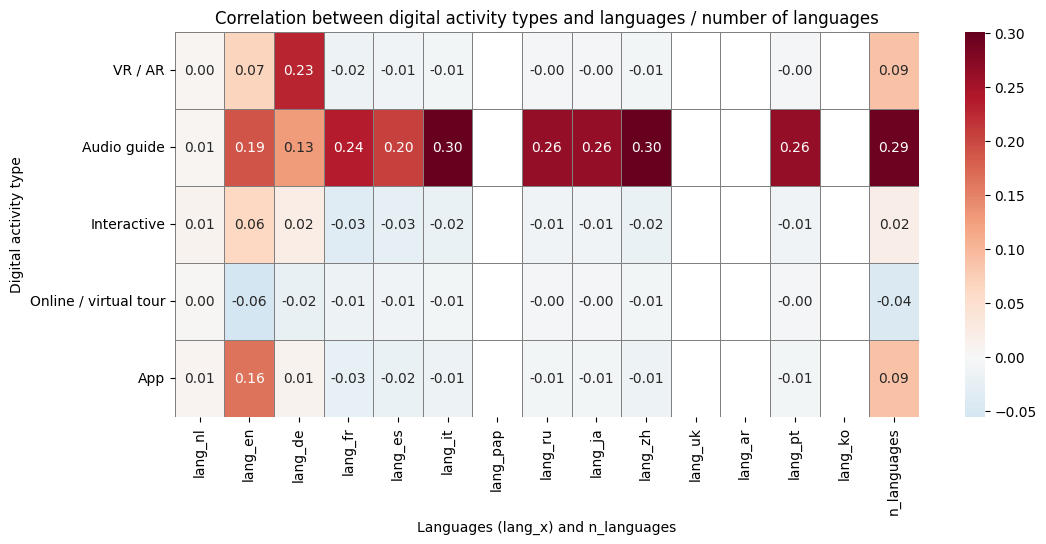


=== BASIC COUNTS (activity level) ===
N activities: 513
Share with digital experience: 0.2826510721247563
Share special-needs accessible (museum-level signal): 0.8011695906432749
Share youth activities: 0.5029239766081871
Share school programs: 0.42300194931773877
Share with migrant-community language: 0.005847953216374269
Average number of languages per activity: 1.345029239766082

=== LANGUAGE PROFILE (activities) ===
lang_profile
nl_only           0.748538
multi_language    0.249513
en_only           0.001949
Name: proportion, dtype: float64

=== MUSEUM-LEVEL STATS ===
N museums: 98
Mean prop_digital: 0.28056347233039647
Mean prop_youth: 0.43267604025423456
Mean prop_migrant_lang: 0.030612244897959183
Share of museums with special-needs access: 0.6938775510204082


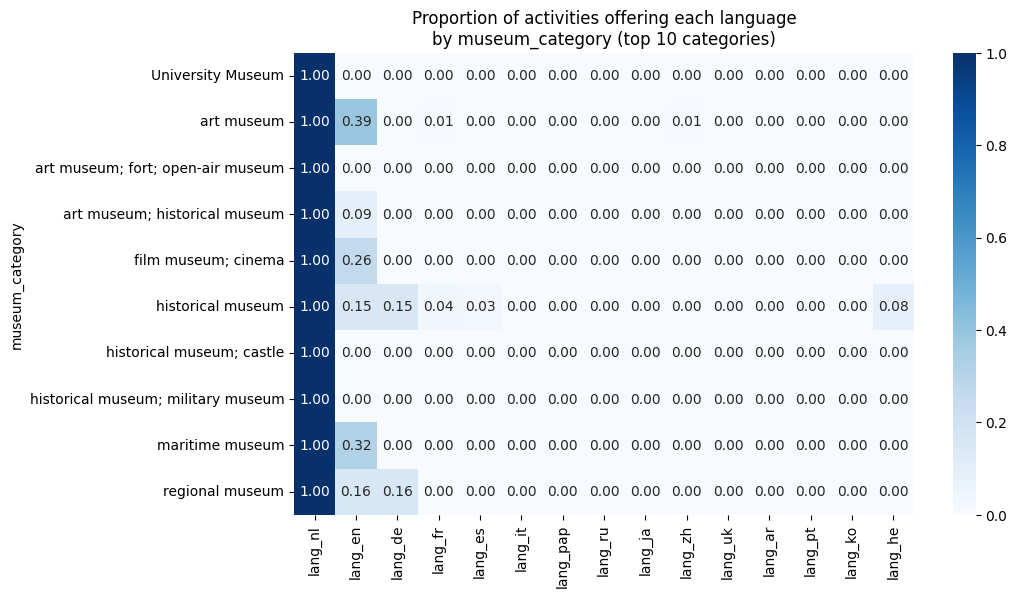

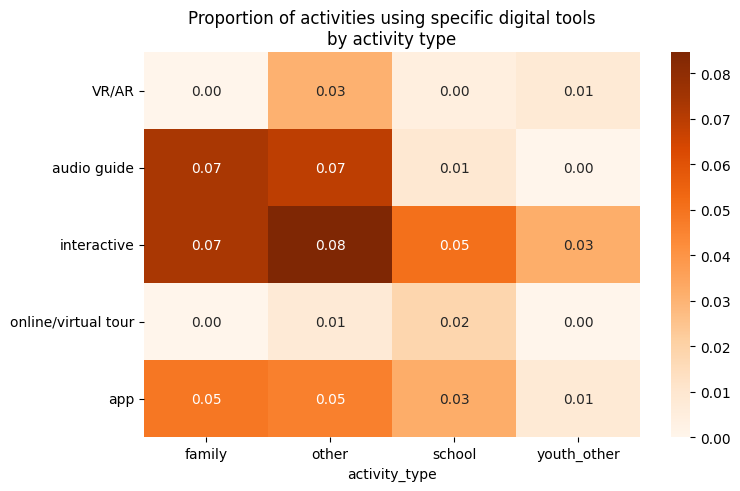

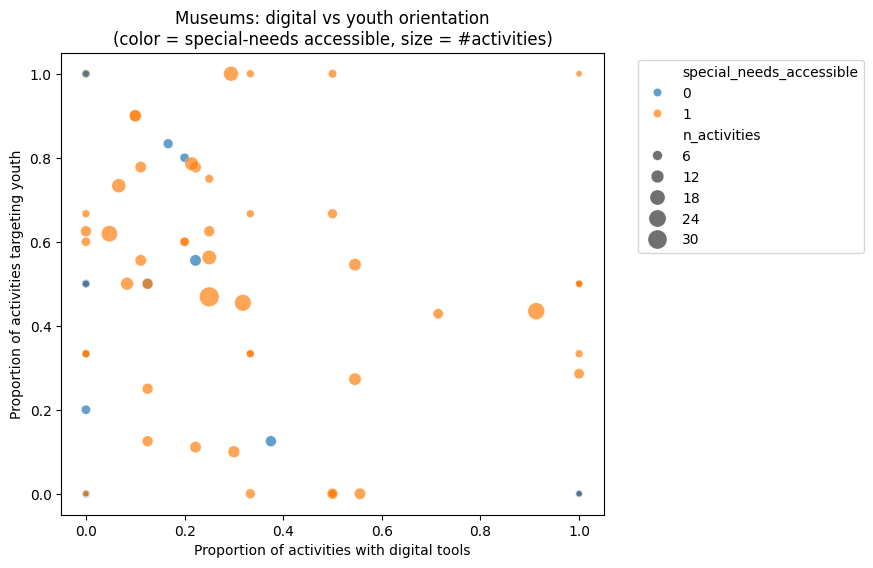


=== CHI-SQUARE TESTS (activity level) ===

Youth activity vs digital experience
has_digital_experience    0   1
is_youth_activity              
0                       164  91
1                       204  54
chi2=13.054, dof=1, p=0.0003

School program vs digital experience
has_digital_experience    0   1
is_school_program              
0                       206  90
1                       162  55
chi2=1.341, dof=1, p=0.2468

Migrant-language vs digital experience
has_digital_experience    0    1
has_migrant_language            
0                       367  143
1                         1    2
chi2=0.703, dof=1, p=0.4018

=== LOGISTIC REGRESSION: digital ~ youth + school + family + migrant_lang + accessibility + n_languages ===
                             Logit Regression Results                             
Dep. Variable:     has_digital_experience   No. Observations:                  513
Model:                              Logit   Df Residuals:                      506
Method:   

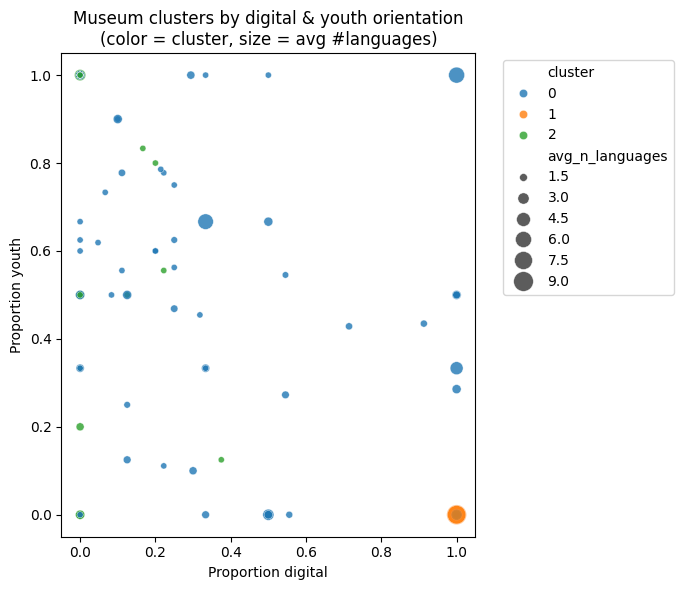

In [26]:

# ---------------- MAIN ----------------

def main():
    # load data
    df = pd.read_csv(DATA_PATH)
    print("Loaded data:", df.shape)

    # engineer activity-level features
    df = engineer_activity_features(df)

    # NEW: correlation heatmap (16.06.)
    heatmap_digital_vs_languages_corr(df)

    # museum-level aggregation
    museum_df = aggregate_museum_level(df)

    # descriptive stats
    descriptive_stats(df, museum_df)

    # visualizations
    heatmap_languages_by_category(df)
    heatmap_digital_types_vs_activity_type(df)
    scatter_digital_vs_youth(museum_df)

    # statistical tests
    chi_square_tests(df)
    logistic_regression(df)

    # clustering (optional)
    cluster_museums(museum_df, k=3)


if __name__ == "__main__":
    main()

The code below is attached to **Section 4.1** <br> It converts age from string into float numeric variables, and calculates the average age of the activities for families.

In [29]:
df = pd.read_csv("/Users/dashailina/Desktop/code/output_clean_1106.csv")

def parse_age_to_number(s):
    """
    Convert target_age strings like:
    - '4-17 years' -> 10.5 (midpoint)
    - '16+ jaar'  -> 16
    - '10 years' or '10 jaar' -> 10
    If cannot parse, return NaN.
    """
    if not isinstance(s, str) or not s.strip():
        return np.nan

    s = s.lower().strip()

    # Range: '4-17', '6–12'
    m = re.search(r'(\d{1,2})\s*[-–]\s*(\d{1,2})', s)
    if m:
        lo, hi = int(m.group(1)), int(m.group(2))
        return (lo + hi) / 2.0

    # '10+ jaar', '12+ years'
    m = re.search(r'(\d{1,2})\s*\+\s*(jaar|years)?', s)
    if m:
        return int(m.group(1))

    # Single age: '10 years', '10 jaar'
    m = re.search(r'(\d{1,2})\s*(jaar|years)', s)
    if m:
        return int(m.group(1))

    return np.nan


# Create numeric age column
df["target_age_num"] = df["target_age"].apply(parse_age_to_number)

# ---- choose ONE of these masks, depending on your dataset ----

# 1) If you have a categorical column "target_group" with value 'family':
family_mask = df["target_group"].str.lower() == "family"

# 2) OR if you used a boolean flag "is_family_activity" (0/1 or True/False):
# family_mask = df["is_family_activity"] == 1

# Compute average age for family activities
avg_family_age = df.loc[family_mask, "target_age_num"].mean()

print("Average target age for family activities:", avg_family_age)

Average target age for family activities: 7.8533333333333335


In [30]:
print(df.loc[family_mask, "target_age_num"].describe())

count    75.000000
mean      7.853333
std       2.529252
min       0.000000
25%       6.000000
50%       8.500000
75%       9.000000
max      14.000000
Name: target_age_num, dtype: float64


The code below is attached to **Section 4.1** <br>
Statistics for the most occurring descriptions of activities targeted towards families.

In [13]:
from collections import Counter

df = pd.read_csv("/Users/dashailina/Desktop/code/output_clean_1106.csv")

# 1) Filter to family activities
# If you have a text column "target_group":
family_mask = df["target_group"].fillna("").str.lower() == "family"

# If you instead use a flag like is_family_activity (0/1), use this instead:
# family_mask = df["is_family_activity"] == 1

df_family = df[family_mask].copy()
titles = df_family["activity_title"].fillna("").str.lower()

print(f"N family activities: {len(df_family)}")

# 2) Function to extract character n-grams (letter combinations)
def char_ngrams(text, n=10):
    # keep only letters and spaces
    text = re.sub(r"[^a-záéíóúäëïöüàèìòùçñ]", " ", text.lower())
    text = re.sub(r"\s+", " ", text).strip()
    grams = []
    for word in text.split():
        if len(word) >= n:
            grams.extend(word[i:i+n] for i in range(len(word) - n + 1))
    return grams

# 3) Count n-grams across all family titles
n = 10   # choose 2 for bigrams, 3 for trigrams, etc.
counter = Counter()

for t in titles:
    counter.update(char_ngrams(t, n=n))

# 4) Show the most frequent n-grams
top_k = 10
for gram, freq in counter.most_common(top_k):
    print(f"{gram}: {freq}")

print(f"\nTotal unique {n}-grams: {len(counter)}")
print(f"Percentage of 'speurtocht' n-grams: {counter['speurtocht'] / len(counter) * 100:.4f}%")

N family activities: 154
speurtocht: 17
playground: 6
rondleidin: 5
ondleiding: 5
ndleidinge: 4
dleidingen: 4
experience: 2
experiment: 2
xperimente: 2
kinderwork: 2

Total unique 10-grams: 191
Percentage of 'speurtocht' n-grams: 8.9005%


The following cell illustrates the presence of language TRUE values across all the dataset. <br>
It relates to **Section 4.1** of the Results.

In [15]:
# count TRUE occurrences and rates for language columns
cols = LANG_COLS if "LANG_COLS" in globals() else [c for c in df.columns if c.startswith("lang_")]

total = len(df)
counts = {c: int(df[c].astype(bool).sum()) for c in cols}
res = pd.DataFrame({
    "lang": list(counts.keys()),
    "count_true": list(counts.values()),
})
res["rate"] = res["count_true"] / total
res = res.sort_values("count_true", ascending=False).reset_index(drop=True)

print("Overall (activity-level):")
print(res)

Overall (activity-level):
        lang  count_true      rate
0    lang_nl         512  0.998051
1    lang_en         121  0.235867
2    lang_de          25  0.048733
3    lang_fr          10  0.019493
4    lang_he           7  0.013645
5    lang_es           6  0.011696
6    lang_it           3  0.005848
7    lang_zh           3  0.005848
8    lang_ru           1  0.001949
9    lang_ja           1  0.001949
10   lang_pt           1  0.001949
11  lang_pap           0  0.000000
12   lang_uk           0  0.000000
13   lang_ar           0  0.000000
14   lang_ko           0  0.000000


**Section 4.1**: calculation of presence of different languages and their proportions.

In [20]:
other_lang_cols = [c for c in cols if c not in ("lang_en", "lang_nl")]
has_other_non_en_lang = df[other_lang_cols].any(axis=1)

en_mask = df["lang_en"].astype(bool)

en_count = int(en_mask.sum())
en_with_other_count = int((en_mask & has_other_non_en_lang).sum())
total_other_non_en = int(has_other_non_en_lang.sum())

print("Records with lang_en TRUE:", en_count, "(", en_count / total * 100, "%)")
print(
    "Records with at least one non-en language TRUE "
    "(excluding lang_en and lang_nl):",
    total_other_non_en,
    "(", total_other_non_en / total * 100, "%)"
)
print("Other language columns considered:", other_lang_cols)

Records with lang_en TRUE: 121 ( 23.586744639376217 %)
Records with at least one non-en language TRUE (excluding lang_en and lang_nl): 29 ( 5.653021442495127 %)
Other language columns considered: ['lang_de', 'lang_fr', 'lang_es', 'lang_it', 'lang_pap', 'lang_ru', 'lang_ja', 'lang_zh', 'lang_uk', 'lang_ar', 'lang_pt', 'lang_ko', 'lang_he']
